# TODO: Title

This notebook lists all the steps that you need to complete the complete this project. You will need to complete all the TODOs in this notebook as well as in the README and the two python scripts included with the starter code.


**TODO**: Give a helpful introduction to what this notebook is for. Remember that comments, explanations and good documentation make your project informative and professional.

**Note:** This notebook has a bunch of code and markdown cells with TODOs that you have to complete. These are meant to be helpful guidelines for you to finish your project while meeting the requirements in the project rubrics. Feel free to change the order of these the TODO's and use more than one TODO code cell to do all your tasks.

In [3]:
# TODO: Install any packages that you might need
# For instance, you will need the smdebug package
!pip install smdebug


[notice] A new release of pip available: 22.3.1 -> 23.0
[notice] To update, run: pip install --upgrade pip


In [4]:

# Command to download and unzip data
!wget https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
!unzip dogImages.zip

--2023-02-07 14:22:39--  https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
Resolving s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)... 52.219.193.48
Connecting to s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)|52.219.193.48|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1132023110 (1.1G) [application/zip]
Saving to: ‘dogImages.zip’

dogImages.zip       100%[===================>]   1.05G  15.0MB/s    in 39s     

2023-02-07 14:23:19 (27.6 MB/s) - ‘dogImages.zip’ saved [1132023110/1132023110]

Archive:  dogImages.zip
   creating: dogImages/
   creating: dogImages/test/
   creating: dogImages/train/
   creating: dogImages/valid/
   creating: dogImages/test/001.Affenpinscher/
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00003.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00023.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00036.jpg  
  inflating: dogImages/test/001.Af

In [11]:
# TODO: Import any packages that you might need
# For instance you will need Boto3 and Sagemaker
import os
import logging

import sagemaker
import boto3
from torchvision import datasets, models, transforms
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from sagemaker.debugger import Rule, ProfilerRule, DebuggerHookConfig, rule_configs

/opt/conda/lib/python3.8/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: 
  warn(f"Failed to load image Python extension: {e}")


## Dataset
TODO: Explain what dataset you are using for this project. Maybe even give a small overview of the classes, class distributions etc that can help anyone not familiar with the dataset get a better understand of it.


The dataset contains 6680 train images, 835 validation images and 837 test images of dogs of 133 breeds. 
Median number of images of each class in training set is 19. Maximum number is 38, minimum - 8

In [12]:
FOLDERS = ['train', 'valid', 'test']

In [13]:
data_transforms = {
    x: transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
    ]) 
    for x in FOLDERS
}

In [14]:
data_dir = 'dogImages'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x]
                                         )
                  for x in FOLDERS}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True)
               for x in FOLDERS}
class_names = image_datasets['train'].classes
NUM_CLASSES = len(class_names)
print("number of classes:{}".format(NUM_CLASSES))

inputs, classes = next(iter(dataloaders['train']))


number of classes:133
[2023-02-15 17:34:52.546 pytorch-1-10-cpu-py38-ml-t3-medium-9c8fa3a7688fa232cbbe37185a11:30 INFO utils.py:27] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2023-02-15 17:34:52.766 pytorch-1-10-cpu-py38-ml-t3-medium-9c8fa3a7688fa232cbbe37185a11:30 INFO profiler_config_parser.py:111] Unable to find config at /opt/ml/input/config/profilerconfig.json. Profiler is disabled.


/opt/conda/lib/python3.8/site-packages/smdebug-1.0.13b20220304-py3.8.egg/smdebug/profiler/system_metrics_reader.py:63: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/opt/conda/lib/python3.8/site-packages/smdebug-1.0.13b20220304-py3.8.egg/smdebug/profiler/system_metrics_reader.py:63: SyntaxWarning: "is not" with a literal. Did you mean "!="?


AttributeError: 'BarContainer' object has no attribute 'show'

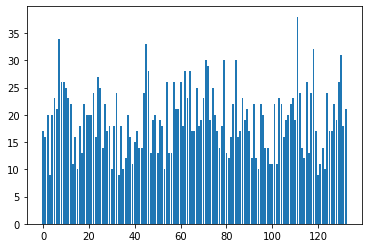

In [15]:
train_values = [len(image_datasets['train'].classes[i]) 
          for i in range(NUM_CLASSES)]

fig = plt.bar(range(NUM_CLASSES), train_values)
fig.show()

In [7]:
print(np.median(train_values), np.max(train_values), np.min(train_values))

19.0 38 9


In [8]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # mean = np.array([0.485, 0.456, 0.406])
    # std = np.array([0.229, 0.224, 0.225])
    # inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated



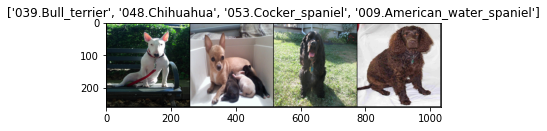

In [9]:
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [10]:
#TODO: Fetch and upload the data to AWS S3
sagemaker_session = sagemaker.Session()
bucket = sagemaker_session.default_bucket()
prefix = "sagemaker/DogBreedClassification"
s3_dataset_path = sagemaker_session.upload_data(path="dogImages", bucket=bucket, key_prefix=prefix)
print("input spec (in this case, just an S3 path): {}".format(s3_dataset_path))

KeyboardInterrupt: 

In [16]:
s3_dataset_path = 's3://sagemaker-us-east-1-222248610835/sagemaker/DogBreedClassification/'

## Hyperparameter Tuning
**TODO:** This is the part where you will finetune a pretrained model with hyperparameter tuning. Remember that you have to tune a minimum of two hyperparameters. However you are encouraged to tune more. You are also encouraged to explain why you chose to tune those particular hyperparameters and the ranges.

**Note:** You will need to use the `hpo.py` script to perform hyperparameter tuning.

In [27]:
from sagemaker.tuner import (
    IntegerParameter,
    CategoricalParameter,
    ContinuousParameter,
    HyperparameterTuner,
)

In [18]:
# rules = [
#     Rule.sagemaker(rule_configs.vanishing_gradient()),
#     Rule.sagemaker(rule_configs.overfit()),
#     Rule.sagemaker(rule_configs.overtraining()),
#     Rule.sagemaker(rule_configs.poor_weight_initialization()),
#     ProfilerRule.sagemaker(rule_configs.ProfilerReport()),
# ]
# hook_config = DebuggerHookConfig(
#     hook_parameters={"train.save_interval": "100", "eval.save_interval": "10"}
# )

In [28]:
#TODO: Declare your HP ranges, metrics etc.
hyperparameter_ranges = {
    "lr": ContinuousParameter(0.001, 0.01),
    "batch-size": CategoricalParameter([16, 32, 64, 128, 256]),
    "momentum": ContinuousParameter(0.0, 0.99),
}

In [29]:
objective_metric_name = "validation:accuracy"
objective_type = "Maximize"
metric_definitions = [{"Name": "validation:accuracy", "Regex": "Validation set: Accuracy: ([0-9\\.]+)"}]

In [30]:
from sagemaker.pytorch import PyTorch
role = sagemaker.get_execution_role()

In [31]:
#TODO: Create estimators for your HPs

estimator =  PyTorch(
    entry_point="hpo.py",
    role=role,
    py_version='py36',
    framework_version="1.8",
    instance_count=1,
    instance_type="ml.m5.large",
    base_job_name="project3-hpo",
    # rules=rules,
    # debugger_hook_config=hook_config,
)

tuner = HyperparameterTuner(
    estimator,
    objective_metric_name,
    hyperparameter_ranges,
    metric_definitions,
    max_jobs=4,
    max_parallel_jobs=2,
    objective_type=objective_type,
)

In [37]:
# TODO: Fit your HP Tuner
tuner.fit(inputs={x:os.path.join(s3_dataset_path,x) for x in FOLDERS},
         wait=True) # TODO: Remember to include your data channels

INFO:sagemaker.image_uris:Defaulting to the only supported framework/algorithm version: latest.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating hyperparameter tuning job with name: pytorch-training-230215-1943


...................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................*


UnexpectedStatusException: Error for HyperParameterTuning job pytorch-training-230215-1943: Failed. Reason: All training jobs failed. Please take a look at the training jobs failures to get more details.

In [4]:
DATA_S3_URL = 's3://sagemaker-us-east-1-222248610835/sagemaker/DogBreedClassification/'

In [ ]:
# TODO: Get the best estimators and the best HPs

best_estimator = #TODO

#Get the hyperparameters of the best trained model
best_estimator.hyperparameters()

## Model Profiling and Debugging
TODO: Using the best hyperparameters, create and finetune a new model

**Note:** You will need to use the `train_model.py` script to perform model profiling and debugging.

In [ ]:
# TODO: Set up debugging and profiling rules and hooks

In [ ]:
# TODO: Create and fit an estimator

estimator = # TODO: Your estimator here

In [ ]:
# TODO: Plot a debugging output.

**TODO**: Is there some anomalous behaviour in your debugging output? If so, what is the error and how will you fix it?  
**TODO**: If not, suppose there was an error. What would that error look like and how would you have fixed it?

In [ ]:
# TODO: Display the profiler output

## Model Deploying

In [ ]:
# TODO: Deploy your model to an endpoint

predictor=estimator.deploy() # TODO: Add your deployment configuration like instance type and number of instances

In [ ]:
# TODO: Run an prediction on the endpoint

image = # TODO: Your code to load and preprocess image to send to endpoint for prediction
response = predictor.predict(image)

In [ ]:
# TODO: Remember to shutdown/delete your endpoint once your work is done
predictor.delete_endpoint()